In [1]:
%load_ext autoreload
%autoreload 2

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import h5py

import sys
sys.path.append('../src/')
from viz import show_images

In [6]:
## from Aaron

import numpy as np

# Define a function to parse an S2P file assuming RI format
def parse_s2p(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Skip header lines and parse data lines
    data_lines = [line for line in lines if not line.startswith('!') and not line.startswith('#')]

    # Initialize lists to store frequencies and S-parameters
    frequencies = []
    s_params = []

    # Process each line of data
    for line in data_lines:
        parts = line.split()
        frequency = float(parts[0])
        # The rest of the parts are S-parameters in RI format
        s_param = np.array([float(part) for part in parts[1:]])
        frequencies.append(frequency)
        s_params.append(s_param)

    return np.array(frequencies), np.array(s_params)

# Example usage
frequencies, s_parameters = parse_s2p('../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_0V_dev.s2p')

In [8]:
frequencies.shape, s_parameters.shape, frequencies.dtype, s_parameters.dtype

((2651,), (2651, 8), dtype('float64'), dtype('float64'))

In [10]:
# with h5py.File('../datasets/LYW034BTONSO25nm-0D16F200V2S-J.h5', 'w') as f:
#     f.create_dataset('frequencies', data=frequencies)
#     f.create_dataset('s_parameters', data=s_parameters)
length = 0
for file in glob.glob('../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/*.s2p'):
    # print(file)
    frequencies, s_parameters = parse_s2p(file)
    # print(frequencies.shape, s_parameters.shape, frequencies.dtype, s_parameters.dtype)
    length += len(frequencies)
print(length)

532851


In [11]:
with h5py.File('../datasets/LYW034BTONSO25nm-0D16F200V2S-J.h5', 'w') as f:
    f.create_dataset('frequencies', shape=(length,), dtype=np.float64)
    f.create_dataset('s_parameters', shape=(length, 8), dtype=np.float64)

    index = 0
    for file in glob.glob('../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/*.s2p'):
        print(file)
        frequencies, s_parameters = parse_s2p(file)
        print(frequencies.shape, s_parameters.shape, frequencies.dtype, s_parameters.dtype)
        f['frequencies'][index:index+len(frequencies)] = frequencies
        f['s_parameters'][index:index+len(frequencies)] = s_parameters
        index += len(frequencies)

../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_0V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_100V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_102V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_104V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_106V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_108V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_10V_dev.s2p
(2651,) (2651, 8) float64 float64
../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P\LYW034BTONSO25nm_0D16F200V2S_J_110V_dev.s2p
(2651,) (2651, 8) float64 float64
../

In [14]:
with h5py.File('../datasets/LYW034BTONSO25nm-0D16F200V2S-J.h5', 'r') as f:
    frequencies, s_parameters = f['frequencies'], f['s_parameters']
    print(frequencies.shape, s_parameters.shape, frequencies.dtype, s_parameters.dtype)
    print(frequencies[:10], s_parameters[:10])

(532851,) (532851, 8) float64 float64
[10000000.       19996226.415094 29992452.830189 39988679.245283
 49984905.660377 59981132.075472 69977358.490566 79973584.90566
 89969811.320755 99966037.735849] [[ 9.9886739e-01 -2.1211803e-03  4.0577876e-04  9.6107455e-04
  -2.2307498e-04  7.8170438e-04  9.9867380e-01 -9.3251467e-04]
 [ 9.9909168e-01 -2.6454926e-03  2.0402583e-04  1.1259650e-03
   8.5420150e-05  1.3568203e-03  9.9929661e-01 -2.6135445e-03]
 [ 9.9970216e-01 -3.2238364e-03  2.8750568e-05  1.8089182e-03
  -1.0572432e-05  1.7787507e-03  9.9949324e-01 -3.5520792e-03]
 [ 1.0000242e+00 -4.1378289e-03  8.9277164e-06  2.4391133e-03
   2.4746172e-05  2.3954131e-03  9.9961382e-01 -4.2119920e-03]
 [ 1.0001308e+00 -5.1543415e-03 -6.3254265e-06  3.0101093e-03
   1.5445286e-05  3.0251169e-03  9.9970198e-01 -5.0856769e-03]
 [ 1.0001335e+00 -6.1773062e-03  1.8999795e-05  3.6372044e-03
   2.1754298e-05  3.6123334e-03  9.9962521e-01 -5.8252215e-03]
 [ 9.9992979e-01 -7.0004743e-03  5.7531550e-05  4

## parse s2p file

Number of frequency points: 2651
S-parameter matrix shape: (2651, 2, 2)


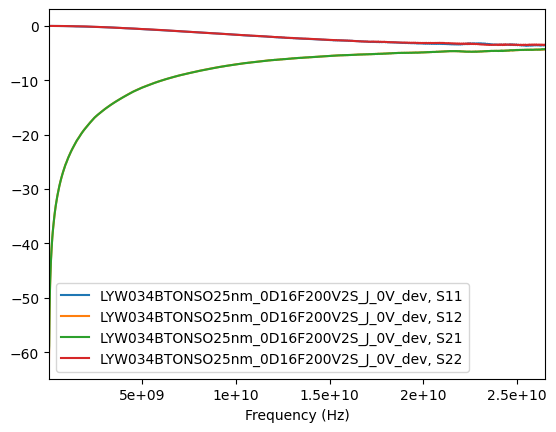

In [3]:
import skrf as rf

# Load the S2P file
network = rf.Network('../datasets/LYW034BTONSO25nm-0D16F200V2S-J/S2P/LYW034BTONSO25nm_0D16F200V2S_J_0V_dev.s2p')

# Access the frequency data
frequencies = network.f

# Access the S-parameters
s_parameters = network.s

# Print some basic information
print(f"Number of frequency points: {len(frequencies)}")
print(f"S-parameter matrix shape: {s_parameters.shape}")

# Access specific S-parameters
s11 = network.s11
s21 = network.s21
s12 = network.s12
s22 = network.s22

# Plot the S-parameters
network.plot_s_db()

In [5]:
network

2-Port Network: 'LYW034BTONSO25nm_0D16F200V2S_J_0V_dev',  10000000.0-26500000000.0 Hz, 2651 pts, z0=[50.+0.j 50.+0.j]